# HGQA MPS and Larger-Case Validation Demo

This notebook is a submission-side companion to `demo.ipynb`. It borrows the working flow from `HGQA_Codespace/HGQA_MPS_Validation.ipynb`, but keeps the runtime modest:

- `small_city`, `N=25`: exact brute force plus MPS-QAOA smoke test with feasible sampled outputs.
- `medium_city`, `N=196`: larger pruning and baseline validation case that reaches about `K=48` after pruning.

The medium MPS run is included as an optional cell because it is useful for simulation validation, but short runs can produce few or zero feasible samples.

In [1]:
import math
import os
import random
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Notebook lives in hgqa-submission/. Keep imports stable whether the
# notebook is opened from this folder or executed from the repo root.
ROOT = Path.cwd()
if (ROOT / 'src').exists():
    SUBMISSION_ROOT = ROOT
else:
    SUBMISSION_ROOT = ROOT / 'hgqa-submission'

sys.path.insert(0, str(SUBMISSION_ROOT / 'src'))

from data_loader import load_dataset, print_dataset_summary
from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    brute_force_ranking,
)
from cell_pruner import prune_cells, remap_qubo_for_qaoa, translate_results
from population_generator import random_population, greedy_population, population_summary
from qaoa_builder import run_qaoa_mps

DATA_DIR = SUBMISSION_ROOT / 'data'
SEED = 42
rng = np.random.default_rng(SEED)

print(f'Using submission root: {SUBMISSION_ROOT}')
print('Imports OK')

Using submission root: /home/unfunnypanda/Proj_HGQA/hgqa-submission
Imports OK


## Helper: Build, Prune, Remap

This follows the same pipeline as the Codespace validation notebook: load Excel data, discretize, calculate weights, suggest/calibrate parameters, build QUBO, prune cells, and remap to contiguous qubit indices.

In [2]:
def run_case(label, dataset_file, n_qubits, grid_division, tier3_keep=3, verbose_grid=False):
    print('=' * 78)
    print(f'CASE: {label}')
    print('=' * 78)

    data = load_dataset(str(DATA_DIR / dataset_file))
    print_dataset_summary(data)

    grid_details, plot_deets = divide_graph_into_parts(
        x_min=data['x_min'], x_max=data['x_max'],
        y_min=data['y_min'], y_max=data['y_max'],
        num_qubits=n_qubits,
        points_of_interest=data['pois'],
        existing_chargers=data['existing_chargers'],
        gas_stations=data['gas_stations'],
        grid_division=grid_division,
    )

    cell_weights = calculate_cell_weights(grid_details, scale_factor=5.0, min_weight=0.5)
    if verbose_grid:
        print_weight_summary(cell_weights, grid_details, top_n=12)

    params = suggest_parameters(grid_details, cell_weights, plot_deets, m=data['m'])
    print_parameter_suggestions(params)

    alpha = params['alpha']
    radii = params['radii']
    intra = params['intra']

    Q_obj, h5_params, diags = build_qubo(
        grid_details=grid_details,
        cell_weights=cell_weights,
        plot_deets=plot_deets,
        m=data['m'],
        alpha1=alpha['a1'], alpha2=alpha['a2'], alpha3=alpha['a3'],
        alpha4=alpha['a4'], alpha5=alpha['a5'], alpha6=alpha['a6'],
        beta=intra['beta'], gamma=intra['gamma'],
        delta=intra['delta'], epsilon=intra['epsilon'],
        lam=params['lambda'],
        R1=radii['R1'], Rs=radii['Rs'], R3=radii['R3'],
        R4=radii['R4'], R6=radii['R6'],
    )

    flat_params = {
        'alpha1': alpha['a1'], 'alpha2': alpha['a2'], 'alpha3': alpha['a3'],
        'alpha4': alpha['a4'], 'alpha5': alpha['a5'], 'alpha6': alpha['a6'],
        'beta': intra['beta'], 'gamma': intra['gamma'],
        'delta': intra['delta'], 'epsilon': intra['epsilon'],
        'lam': params['lambda'],
        'R1': radii['R1'], 'Rs': radii['Rs'], 'R3': radii['R3'],
        'R4': radii['R4'], 'R6': radii['R6'],
    }

    flat_params, needs_rebuild = calibrate_alphas(Q_obj, flat_params, diags, verbose=True)
    if needs_rebuild:
        Q_obj, h5_params, diags = build_qubo(
            grid_details=grid_details,
            cell_weights=cell_weights,
            plot_deets=plot_deets,
            m=data['m'],
            **flat_params,
        )

    N = plot_deets['total_cells']
    surviving_cells, prune_report = prune_cells(
        Q_obj=Q_obj,
        N=N,
        m=data['m'],
        num_cols=plot_deets['num_cols'],
        R4=flat_params['R4'],
        tier3_keep=tier3_keep,
        verbose=True,
    )

    Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)
    K = len(surviving_cells)
    before = math.comb(N, data['m'])
    after = math.comb(K, data['m'])

    print('\nRemap summary')
    print(f'  N -> K:       {N} -> {K}')
    print(f'  Q entries:    {len(Q_obj)} -> {len(Q_pruned)}')
    print(f'  Search space: C({N},{data["m"]})={before:,} -> C({K},{data["m"]})={after:,}')

    return {
        'label': label,
        'data': data,
        'N': N,
        'K': K,
        'grid_details': grid_details,
        'plot_deets': plot_deets,
        'cell_weights': cell_weights,
        'Q_obj': Q_obj,
        'h5_params': h5_params,
        'Q_pruned': Q_pruned,
        'surviving_cells': surviving_cells,
        'cell_to_qubit': cell_to_qubit,
        'qubit_to_cell': qubit_to_cell,
        'prune_report': prune_report,
        'params': flat_params,
    }

## Case 1: Small City, but Larger Than the Original Demo's Pruned QUBO

The original `demo.ipynb` prunes its synthetic case to `K=11`. This case keeps the bundled `small_city` dataset at `K=25`, which is still exact-solvable but large enough to exercise the MPS simulator meaningfully.

CASE: small_city N=25
Dataset: small_city
  15 POIs, 4 clusters + scattered, m=4. Good for brute-force validation.
  Area: [0.0, 25.0] × [0.0, 27.0]
  POIs: 15  |  Chargers: 4  |  Gas: 4  |  m=4
  Density range: [0.38, 0.94]  mean=0.59


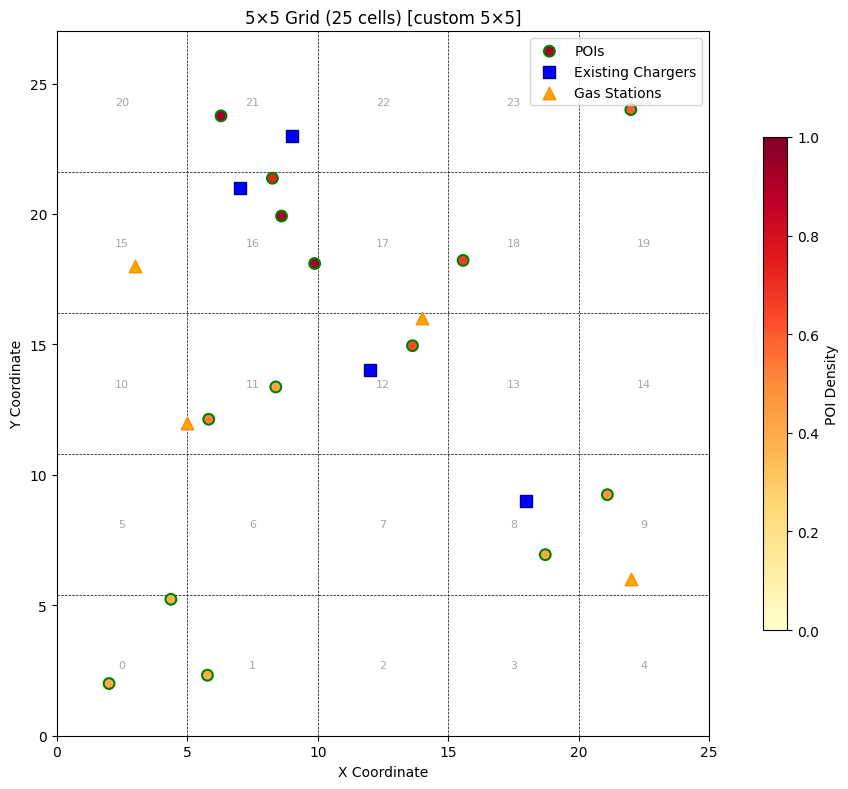

  Grid Info:
    Grid    0 (row=0, col=0): 2 POI(s) [densities: 0.38, 0.40]
    Grid    1 (row=0, col=1): 1 POI(s) [densities: 0.38]
    Grid    8 (row=1, col=3): 1 POI(s) [densities: 0.42] | 1 charger(s)
    Grid    9 (row=1, col=4): 2 POI(s) [densities: 0.47, 0.38] | 1 gas station(s)
    Grid   11 (row=2, col=1): 2 POI(s) [densities: 0.53, 0.42] | 1 gas station(s)
    Grid   12 (row=2, col=2): 1 POI(s) [densities: 0.63] | 1 charger(s) | 1 gas station(s)
    Grid   15 (row=3, col=0): 1 gas station(s)
    Grid   16 (row=3, col=1): 3 POI(s) [densities: 0.91, 0.94, 0.73] | 1 charger(s)
    Grid   18 (row=3, col=3): 1 POI(s) [densities: 0.67]
    Grid   21 (row=4, col=1): 1 POI(s) [densities: 0.93] | 1 charger(s)
    Grid   24 (row=4, col=4): 1 POI(s) [densities: 0.60]
CELL WEIGHT SUMMARY
------------------------  ----------
Total cells               25
Cells with POIs           10 (40.0%)
Total aggregated density  8.79
Max weight                5.00
Min non-zero weight       0.74
Total g

In [3]:
small_case = run_case(
    label='small_city N=25',
    dataset_file='dataset_small_city.xlsx',
    n_qubits=25,
    grid_division=[5, 5],
    verbose_grid=True,
)

In [4]:
M = small_case['data']['m']
K = small_case['K']
Q_pruned = small_case['Q_pruned']

print(f'Exact brute force on pruned small case: C({K},{M}) = {math.comb(K, M):,}')
small_bf = brute_force_ranking(Q_pruned, K, M, top_k=8)
small_bf_cells = [
    (score, [small_case['qubit_to_cell'][q] for q in qubits])
    for score, qubits in small_bf
]

for rank, (score, cells) in enumerate(small_bf_cells, 1):
    print(f'{rank:>2}. score={score:>9.4f}  cells={sorted(cells)}')

Exact brute force on pruned small case: C(25,4) = 12,650
 1. score=  -8.5371  cells=[0, 9, 11, 12]
 2. score=  -8.4961  cells=[9, 11, 12, 23]
 3. score=  -8.4555  cells=[9, 11, 12, 18]
 4. score=  -8.4201  cells=[0, 9, 11, 18]
 5. score=  -8.3713  cells=[9, 11, 16, 18]
 6. score=  -8.2923  cells=[1, 9, 11, 12]
 7. score=  -8.1954  cells=[9, 11, 16, 23]
 8. score=  -8.1850  cells=[1, 9, 11, 18]


## MPS-QAOA Smoke Test on the `K=25` Case

This is intentionally shallow (`p=1`, one restart) so the notebook remains easy to rerun. It is not meant to claim best possible QAOA quality; it verifies the MPS path, returns feasible sampled placements, and ranks them by exact QUBO score.

In [5]:
small_mps_results, small_mps_params = run_qaoa_mps(
    small_case['Q_pruned'],
    small_case['h5_params'],
    N=small_case['K'],
    m=small_case['data']['m'],
    p=1,
    max_iter=8,
    shots=2048,
    n_restarts=1,
    seed=SEED,
    verbose=True,
    max_bond_dimension=16,
    truncation_threshold=1e-8,
    include_h5=True,
)

small_mps_cells = translate_results(small_mps_results, small_case['qubit_to_cell'])
print('\nTop MPS sampled feasible placements')
for rank, (score, cells, prob) in enumerate(small_mps_cells, 1):
    print(f'{rank:>2}. score={score:>9.4f}  emp_prob={prob:.5f}  cells={cells}')

if small_mps_cells:
    print(f'\nExact optimum score: {small_bf[0][0]:.4f}')
    print(f'MPS top sampled score: {small_mps_cells[0][0]:.4f}')
    print(f'Gap: {small_mps_cells[0][0] - small_bf[0][0]:.4f}')

QAOA MPS Pipeline: N=25, m=4, p=1, restarts=1, max_iter=8, shots=2048, top_k=6
  AerSimulator: method=matrix_product_state, bond_dim=16, trunc=1e-08, measure_algo=mps_apply_measure, threads=12
  H5 INCLUDED: adds 300 all-to-all ZZ terms to circuit
  QAOA circuit: 2 parameters, 1000 gates (post-transpile)
  Restart 1/1: cost=-4013.073514 (shifted), raw=2262.947215, evals=8
  Best shifted cost: -4013.073514 (raw: 2262.947215)
  Feasible sampled shots (popcount=4): 12/2048 = 0.0059
  Unique feasible sampled solutions: 11
  Returning top 6
  MPS metadata: {'matrix_product_state_max_bond_dimension': 16, 'matrix_product_state_truncation_threshold': 1e-08}

Top MPS sampled feasible placements
 1. score=  -6.1004  emp_prob=0.00049  cells=[8, 11, 19, 23]
 2. score=  -5.7615  emp_prob=0.00049  cells=[7, 8, 11, 24]
 3. score=  -5.6956  emp_prob=0.00049  cells=[6, 8, 11, 21]
 4. score=  -5.6130  emp_prob=0.00049  cells=[6, 8, 12, 24]
 5. score=  -5.4227  emp_prob=0.00049  cells=[2, 8, 9, 12]
 6. s

## Case 2: Medium City, `N=196`

This is the more meaningful pruning case from the technical report. It is too large for a casual full brute-force run over the original space, but after pruning it becomes a useful candidate for MPS/GA experiments.

CASE: medium_city N=196
Dataset: medium_city
  25 POIs, 6 clusters + corridors, m=5. Tests pruning at 144-400 cells.
  Area: [0.0, 28.0] × [0.0, 27.0]
  POIs: 25  |  Chargers: 6  |  Gas: 5  |  m=5
  Density range: [0.30, 0.97]  mean=0.56


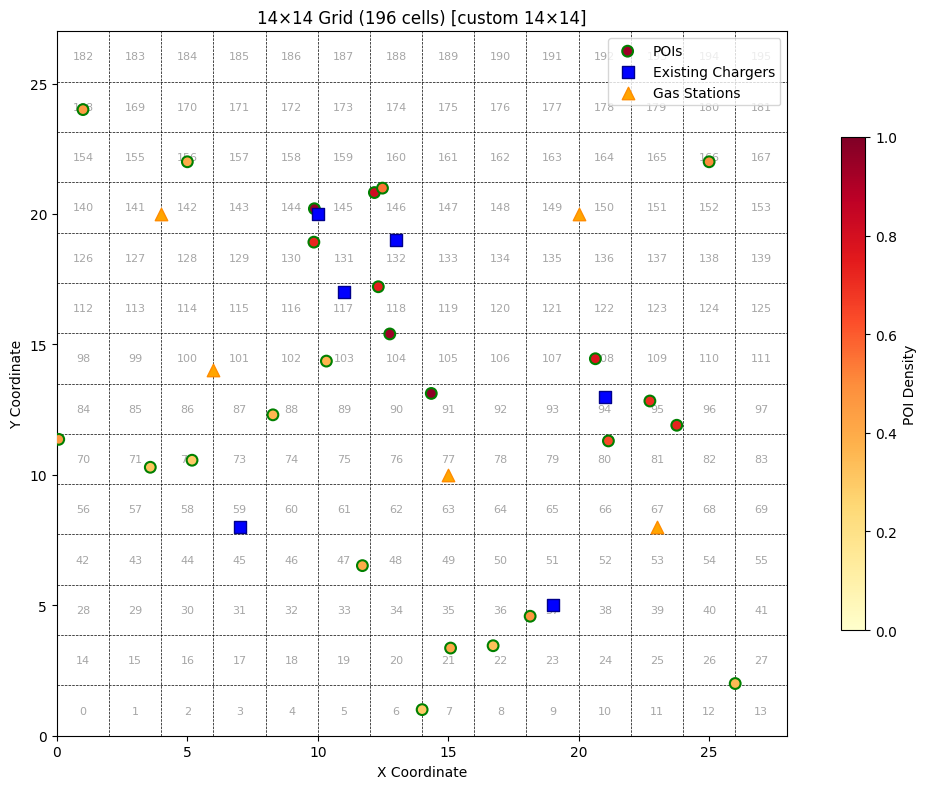

  Grid Info:
    Grid    7 (row=0, col=7): 1 POI(s) [densities: 0.30]
    Grid   21 (row=1, col=7): 1 POI(s) [densities: 0.41]
    Grid   22 (row=1, col=8): 1 POI(s) [densities: 0.33]
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.35]
    Grid   37 (row=2, col=9): 1 POI(s) [densities: 0.47] | 1 charger(s)
    Grid   47 (row=3, col=5): 1 POI(s) [densities: 0.40]
    Grid   59 (row=4, col=3): 1 charger(s)
    Grid   67 (row=4, col=11): 1 gas station(s)
    Grid   70 (row=5, col=0): 1 POI(s) [densities: 0.46]
    Grid   71 (row=5, col=1): 1 POI(s) [densities: 0.32]
    Grid   72 (row=5, col=2): 1 POI(s) [densities: 0.30]
    Grid   77 (row=5, col=7): 1 gas station(s)
    Grid   80 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid   88 (row=6, col=4): 1 POI(s) [densities: 0.36]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.97]
    Grid   94 (row=6, col=10): 1 charger(s)
    Grid   95 (row=6, col=11): 2 POI(s) [densities: 0.73, 0.70]
    Grid  101 (row=7, col=3): 1 gas stat

In [6]:
medium_case = run_case(
    label='medium_city N=196',
    dataset_file='dataset_medium_city.xlsx',
    n_qubits=196,
    grid_division=[14, 14],
    verbose_grid=False,
)

In [7]:
M = medium_case['data']['m']
K = medium_case['K']
Q_pruned = medium_case['Q_pruned']

print(f'Medium pruned search space: C({K},{M}) = {math.comb(K, M):,}')

greedy_pop = greedy_population(Q_pruned, K, M, size=8, rng=SEED)
random_pop = random_population(K, M, size=1000, rng=SEED)

def score_chromosome(chrom):
    return evaluate_solution(Q_pruned, list(np.where(chrom == 1)[0]))

greedy_scores = sorted(score_chromosome(chrom) for chrom in greedy_pop)
random_scores = sorted(score_chromosome(chrom) for chrom in random_pop)

print('Greedy-seeded population')
print(f'  best={greedy_scores[0]:.4f}  median={np.median(greedy_scores):.4f}')
print('Random population, 1000 samples')
print(f'  best={random_scores[0]:.4f}  median={np.median(random_scores):.4f}')

base_greedy_qubits = list(np.where(greedy_pop[0] == 1)[0])
base_greedy_cells = [medium_case['qubit_to_cell'][q] for q in base_greedy_qubits]
print(f'Greedy base cells: {sorted(base_greedy_cells)}')

Medium pruned search space: C(48,5) = 1,712,304
Greedy-seeded population
  best=-13.1630  median=-11.6722
Random population, 1000 samples
  best=-13.1630  median=-9.5986
Greedy base cells: [91, 95, 101, 134, 146]


## Optional: Medium MPS Smoke Run

Set `RUN_MEDIUM_MPS = True` to exercise Aer MPS on the `K=48` medium case. A very short run may return zero feasible samples, which is still useful as a simulator/circuit smoke test. Increase `shots` and `max_iter` for a serious run.

In [8]:
RUN_MEDIUM_MPS = False

if RUN_MEDIUM_MPS:
    medium_mps_results, medium_mps_params = run_qaoa_mps(
        medium_case['Q_pruned'],
        medium_case['h5_params'],
        N=medium_case['K'],
        m=medium_case['data']['m'],
        p=1,
        max_iter=20,
        shots=5000,
        n_restarts=1,
        seed=SEED,
        verbose=True,
        max_bond_dimension=16,
        truncation_threshold=1e-6,
        include_h5=True,
    )
    medium_mps_cells = translate_results(medium_mps_results, medium_case['qubit_to_cell'])
    for rank, (score, cells, prob) in enumerate(medium_mps_cells, 1):
        print(f'{rank:>2}. score={score:>9.4f}  emp_prob={prob:.5f}  cells={cells}')
else:
    print('Medium MPS skipped. Set RUN_MEDIUM_MPS = True to run the K=48 MPS smoke test.')

Medium MPS skipped. Set RUN_MEDIUM_MPS = True to run the K=48 MPS smoke test.


In [9]:
print('=' * 78)
print('SUMMARY')
print('=' * 78)
for case in [small_case, medium_case]:
    data = case['data']
    N = case['N']
    K = case['K']
    M = data['m']
    print(f"{case['label']}: {data['dataset_name']}  m={M}")
    print(f'  pruning: {N} -> {K} ({100 * (1 - K / N):.1f}% reduction)')
    print(f'  search:  C({N},{M})={math.comb(N, M):,} -> C({K},{M})={math.comb(K, M):,}')
    print(f"  tiers:   T1={case['prune_report']['tier1']['pruned']} "
          f"T2={case['prune_report']['tier2']['pruned']} "
          f"T3={case['prune_report']['tier3']['pruned']}")
print('=' * 78)

SUMMARY
small_city N=25: small_city  m=4
  pruning: 25 -> 25 (0.0% reduction)
  search:  C(25,4)=12,650 -> C(25,4)=12,650
  tiers:   T1=0 T2=0 T3=0
medium_city N=196: medium_city  m=5
  pruning: 196 -> 48 (75.5% reduction)
  search:  C(196,5)=2,289,653,184 -> C(48,5)=1,712,304
  tiers:   T1=0 T2=148 T3=0
